# ADFA-LD Host Preprocessing and Analysis

This notebook uses the existing `HostLogPreprocessor` to convert each ADFA-LD syscall trace into overlapping, embedded windows. It summarizes those actual `PreprocessedData.x` windows into one analysis row per source trace and saves `submission/ADFA-LD_host_preprocessed.csv` for analysis and submission.

The preprocessor's embeddings are randomized by default; this notebook resets the random seed before each trace so the same syscall vocabulary maps consistently across files. CNN source code and DBSCAN source code are not modified. The CSV is a compact summary of the preprocessor output, not a replacement for the full window tensor.

## 1. Locate the dataset and read the syscall vocabulary

The setup cell finds the repository root from the notebook's current directory, loads the supplied syscall-ID mapping, and defines the source and submission paths. The submission folder is created by the export cell if it does not already exist.

**Model connection:** the fixed syscall mapping gives a stable feature schema across traces, which is essential for CNN input channels and comparable DBSCAN distances. Keep the vocabulary consistent across train, validation, and future test data. The source paths and labels are provenance only; do not pass them as model features.

In [22]:
from collections import Counter
from math import log2
from pathlib import Path
import csv
import os
import random
import re
import sys

import matplotlib.pyplot as plt
import numpy as np

workspace_root = Path.cwd()
while not (workspace_root / "dat" / "HostLogs" / "ADFA-LD_Syscall_List.txt").is_file():
    parent = workspace_root.parent
    if parent == workspace_root:
        raise FileNotFoundError("Could not find the ADFA-LD syscall list from the current directory.")
    workspace_root = parent

os.chdir(workspace_root)
sys.path[:0] = [str(workspace_root / "src"), str(workspace_root / "src" / "NeuralNet")]
from NeuralNet.HostLogPreprocessor import HostLogPreprocessor
from NeuralNet.NNUtils import AnomalyType, Format, Model, PreprocessingState

logs_root = workspace_root / "dat" / "HostLogs" / "ADFA-LD_Logs"
syscall_list_path = workspace_root / "dat" / "HostLogs" / "ADFA-LD_Syscall_List.txt"
submission_dir = workspace_root / "submission"
csv_path = submission_dir / "ADFA-LD_host_preprocessed.csv"
EMBEDDING_SEED = 4107

syscall_names = {}
syscall_pattern = re.compile(r"#define\s+__NR_(\w+)\s+(\d+)")
with syscall_list_path.open("r", encoding="utf-8", errors="ignore") as syscall_file:
    for line in syscall_file:
        match = syscall_pattern.match(line)
        if match:
            syscall_names[int(match.group(2))] = match.group(1)

if not syscall_names:
    raise ValueError(f"No syscall IDs were parsed from {syscall_list_path}")

custom_arch_ids = set(range(244, 260))
print(f"Workspace: {workspace_root}")
print(f"Known syscall IDs: {len(syscall_names)}")
print(f"Log dataset: {logs_root}")
print(f"Submission CSV: {csv_path}")

Workspace: c:\InnoProject\SLogAn
Known syscall IDs: 293
Log dataset: c:\InnoProject\SLogAn\dat\HostLogs\ADFA-LD_Logs
Submission CSV: c:\InnoProject\SLogAn\submission\ADFA-LD_host_preprocessed.csv


## 2. Preprocess and export trace-level summaries

This cell calls the existing `HostLogPreprocessor` for every training-normal, validation-normal, and attack trace. It reconstructs the embedded event sequence from the class's overlapping 10-event windows, then summarizes event count, syscall diversity, entropy, vocabulary coverage, and per-syscall rates. The CSV stores one summary row per trace with partition, family, binary label, and source path.

**Expected output:** processed trace counts by partition, skipped-file details if any, feature-column count, and the submission CSV path.

**Model connection:** the preprocessor's full `PreprocessedData.x` (one trace's `[windows, 10, 4]` array) is the CNN-shaped data; the CSV is a reduced per-trace summary for data analysis and possible DBSCAN features. For DBSCAN, exclude label and provenance columns, cluster one class at a time, and use labels only afterward to describe cluster composition. The CNN and DBSCAN source files are unchanged.

In [23]:
attack_types = {
    "Adduser": AnomalyType.ADDUSER,
    "Hydra_FTP": AnomalyType.HYDRAFTP,
    "Hydra_SSH": AnomalyType.HYDRASSH,
    "Meterpreter": AnomalyType.METERPRETER,
    "Java_Meterpreter": AnomalyType.JAVAMETERPRETER,
    "Web_Shell": AnomalyType.WEBSHELL,
}
padding_embedding = None


def extract_trace_features(trace_path, partition, family, label):
    is_attack = label == 1
    state_config = PreprocessingState(
        model=Model.CONVOLUTIONAL,
        logFormat=Format.ADFALD,
        logName=trace_path.name,
        logPath=trace_path,
        isTraining=partition != "validation_normal",
        isAnomalous=is_attack,
        anomalyType=attack_types.get(family, AnomalyType.UNK),
        isHostLog=True,
        doDebug=False,
    )

    random.seed(EMBEDDING_SEED)
    preprocessor = HostLogPreprocessor(state_config)
    state, preprocessed = preprocessor.GetStateData()
    windows = np.asarray(preprocessed.x, dtype=np.float32)
    if windows.ndim != 3 or windows.shape[1:] != (10, 4):
        raise ValueError(f"Unexpected preprocessor output shape {windows.shape} for {trace_path}")

    # Consecutive preprocessor windows overlap by nine events; retain the first
    # window and each following window's final event to restore the sequence.
    if len(windows) == 1:
        embedded_sequence = windows[0]
    else:
        embedded_sequence = np.concatenate((windows[0], windows[1:, -1, :]), axis=0)

    embedding_key_by_vector = {
        tuple(np.asarray(vector, dtype=np.float32)): key
        for key, vector in state.embedding.items()
    }
    pad_vector = tuple(np.asarray(state.embedding[9999], dtype=np.float32))
    processed_ids = []
    for vector in embedded_sequence:
        vector_key = tuple(vector)
        if vector_key == pad_vector:
            continue
        processed_ids.append(embedding_key_by_vector.get(vector_key, 0))

    counts = Counter(processed_ids)
    event_count = sum(counts.values())
    if event_count == 0:
        raise ValueError(f"No non-padding preprocessed events for {trace_path}")

    entropy = -sum(
        (count / event_count) * log2(count / event_count)
        for count in counts.values()
    )
    known_count = sum(
        count for key, count in counts.items()
        if key > 0 and key != 9999 and key - 1 in syscall_names
    )
    custom_count = sum(
        count for key, count in counts.items()
        if key > 0 and key - 1 in custom_arch_ids
    )
    unknown_count = event_count - known_count - custom_count

    features = {
        "event_count": event_count,
        "preprocessed_window_count": len(windows),
        "invalid_token_count": 0,
        "unique_syscalls": len(counts),
        "syscall_entropy_bits": entropy,
        "known_syscall_rate": known_count / event_count,
        "custom_arch_rate": custom_count / event_count,
        "other_unknown_rate": unknown_count / event_count,
    }
    for syscall_id in sorted(syscall_names):
        vocab_key = syscall_id + 1
        features[f"syscall_rate_{syscall_id}_{syscall_names[syscall_id]}"] = counts.get(vocab_key, 0) / event_count
    return features


def collect_trace_rows():
    trace_specs = []
    training_dir = logs_root / "Training_Data_Master"
    validation_dir = logs_root / "Validation_Data_Master"
    attack_root = logs_root / "Attack_Data_Master"

    for path in sorted(training_dir.glob("*.txt")):
        trace_specs.append((path, "training_normal", "normal", 0))
    for path in sorted(validation_dir.glob("*.txt")):
        trace_specs.append((path, "validation_normal", "normal", 0))
    for family_dir in sorted(path for path in attack_root.iterdir() if path.is_dir()):
        family = re.sub(r"_\d+$", "", family_dir.name)
        for path in sorted(family_dir.rglob("*.txt")):
            trace_specs.append((path, "attack", family, 1))

    rows = []
    skipped_traces = []
    partition_counts = Counter()
    for trace_path, partition, family, label in trace_specs:
        try:
            features = extract_trace_features(trace_path, partition, family, label)
        except Exception as error:
            skipped_traces.append((trace_path, str(error)))
            continue
        row = {
            "partition": partition,
            "family": family,
            "label": label,
            "source_file": trace_path.relative_to(logs_root).as_posix(),
            **features,
        }
        rows.append(row)
        partition_counts[partition] += 1
    return rows, skipped_traces, partition_counts


host_rows, skipped_traces, partition_counts = collect_trace_rows()
if not host_rows:
    raise ValueError("No traces produced usable HostLogPreprocessor output.")

metadata_columns = ["partition", "family", "label", "source_file"]
feature_columns = [key for key in host_rows[0] if key not in metadata_columns]
fieldnames = metadata_columns + feature_columns
submission_dir.mkdir(parents=True, exist_ok=True)
with csv_path.open("w", newline="", encoding="utf-8") as output_file:
    writer = csv.DictWriter(output_file, fieldnames=fieldnames)
    writer.writeheader()
    writer.writerows(host_rows)

print(f"Exported preprocessed traces: {len(host_rows):,}")
print(f"Rows by partition: {dict(partition_counts)}")
print(f"Skipped traces: {len(skipped_traces)}")
for trace_path, reason in skipped_traces[:5]:
    print(f"Skipped {trace_path.relative_to(logs_root)}: {reason}")
print(f"Feature columns: {len(feature_columns)} ({len(syscall_names)} syscall-rate features)")
print(f"CSV size: {csv_path.stat().st_size / (1024 ** 2):.2f} MiB")

Exported preprocessed traces: 5,951
Rows by partition: {'training_normal': 833, 'validation_normal': 4372, 'attack': 746}
Skipped traces: 0
Feature columns: 301 (293 syscall-rate features)
CSV size: 9.05 MiB


## 3. Load and summarize the preprocessor-derived CSV

This cell reloads the exported, per-trace summaries of `PreprocessedData.x`, checks class labels and that the known/custom/unknown rates sum to approximately one, then reports event count, preprocessed window count, syscall diversity, entropy, and attack-family counts by partition.

**Expected output:** class and partition counts, feature averages/medians, and the attack-family counts.

**Model connection:** labels and class counts help plan supervised classification and choose metrics that account for imbalance. The CSV contains summaries, not the complete ordered windows. The actual CNN-shaped input is `PreprocessedData.x` (`windows x 10 x 4`) produced by `HostLogPreprocessor`; this CSV is a compact analysis/DBSCAN view. For DBSCAN, cluster a single class without its label column, then use labels to interpret the resulting groups.

In [24]:
with csv_path.open("r", newline="", encoding="utf-8") as input_file:
    exported_rows = list(csv.DictReader(input_file))
if not exported_rows:
    raise ValueError(f"Exported CSV is empty: {csv_path}")

partition_order = ["training_normal", "validation_normal", "attack"]
print(f"Loaded {len(exported_rows):,} exported traces from {csv_path.relative_to(workspace_root)}")
print("\nClass counts:")
for label in (0, 1):
    print(f"label {label}: {sum(int(row['label']) == label for row in exported_rows):,}")

rate_sum_errors = 0
for row in exported_rows:
    rate_sum = float(row["known_syscall_rate"]) + float(row["custom_arch_rate"]) + float(row["other_unknown_rate"])
    if not np.isclose(rate_sum, 1.0, atol=1e-9):
        rate_sum_errors += 1
print(f"Rows whose known/custom/unknown rates do not sum to 1: {rate_sum_errors}")

summary_features = ["event_count", "unique_syscalls", "syscall_entropy_bits", "known_syscall_rate"]
print("\nPartition summary (mean / median):")
for partition in partition_order:
    group = [row for row in exported_rows if row["partition"] == partition]
    if not group:
        continue
    print(f"{partition}: n={len(group):,}")
    for feature in summary_features:
        values = np.asarray([float(row[feature]) for row in group])
        print(f"  {feature}: {values.mean():.3f} / {np.median(values):.3f}")

attack_family_counts = Counter(row["family"] for row in exported_rows if row["partition"] == "attack")
print("\nAttack traces by family:")
for family, count in attack_family_counts.most_common():
    print(f"{family}: {count:,}")

Loaded 5,951 exported traces from submission\ADFA-LD_host_preprocessed.csv

Class counts:
label 0: 5,205
label 1: 746
Rows whose known/custom/unknown rates do not sum to 1: 0

Partition summary (mean / median):
training_normal: n=833
  event_count: 381.214 / 210.000
  unique_syscalls: 17.818 / 18.000
  syscall_entropy_bits: 2.848 / 3.099
  known_syscall_rate: 0.908 / 0.941
validation_normal: n=4,372
  event_count: 496.756 / 348.000
  unique_syscalls: 19.916 / 22.000
  syscall_entropy_bits: 3.039 / 3.409
  known_syscall_rate: 0.928 / 0.968
attack: n=746
  event_count: 431.591 / 290.000
  unique_syscalls: 10.209 / 8.000
  syscall_entropy_bits: 2.266 / 2.133
  known_syscall_rate: 0.838 / 0.901

Attack traces by family:
Hydra_SSH: 176
Hydra_FTP: 162
Java_Meterpreter: 124
Web_Shell: 118
Adduser: 91
Meterpreter: 75


## 4. Compare preprocessor-derived trace summaries

This cell plots each trace's event count, number of distinct preprocessed syscall IDs, and syscall entropy across training-normal, validation-normal, and attack partitions. It also compares known-syscall coverage by attack family.

**Expected output:** distribution plots showing how these summaries vary across partitions and attack families. The overlap and outliers help identify which preprocessor-derived features may be useful for modeling.

**Model connection:** the plots guide analysis of the CNN's class separation, but they do not evaluate the CNN; classification metrics require held-out trace-level predictions. For DBSCAN, the same numeric summary columns are candidate features after selecting one class and scaling them. Cluster meaning must come from comparing each cluster's feature averages with that class's overall averages.

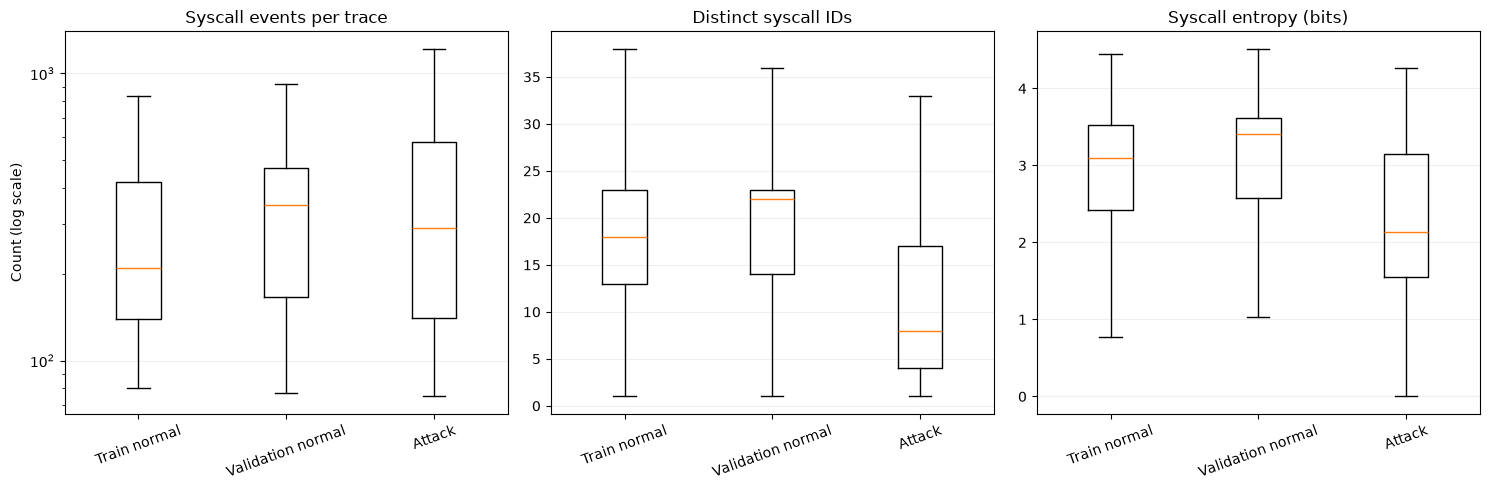

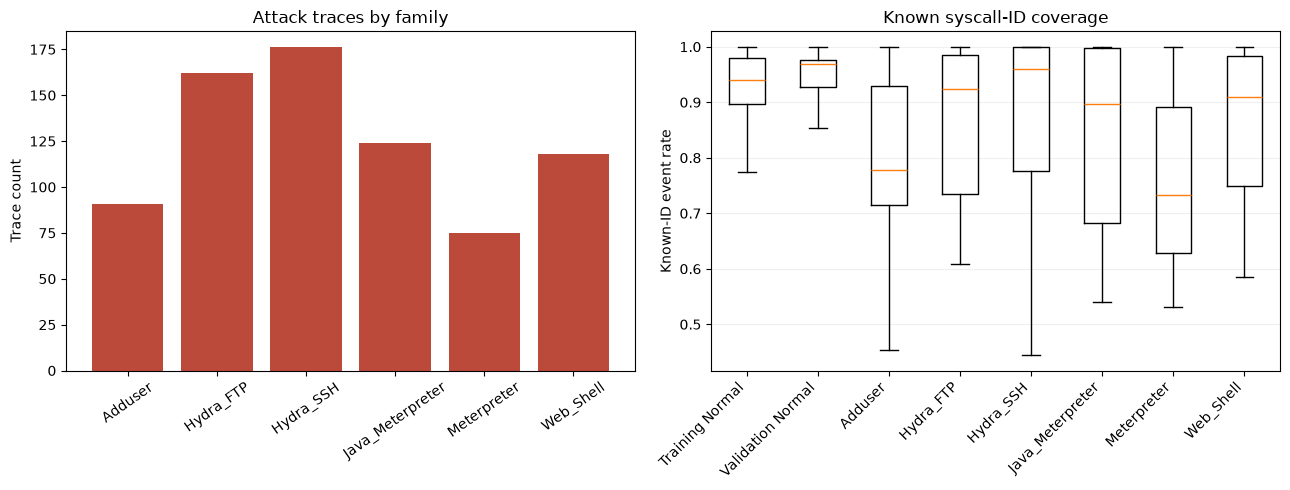

In [25]:
colors = {"training_normal": "#26734d", "validation_normal": "#3976a8", "attack": "#bb4a3b"}
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for axis, feature, title in zip(
    axes,
    ["event_count", "unique_syscalls", "syscall_entropy_bits"],
    ["Syscall events per trace", "Distinct syscall IDs", "Syscall entropy (bits)"],
):
    values_by_partition = [
        [float(row[feature]) for row in exported_rows if row["partition"] == partition]
        for partition in partition_order
    ]
    axis.boxplot(values_by_partition, showfliers=False)
    axis.set_xticks(range(1, len(partition_order) + 1), ["Train normal", "Validation normal", "Attack"], rotation=20)
    axis.set_title(title)
    axis.grid(axis="y", alpha=0.2)
axes[0].set_yscale("log")
axes[0].set_ylabel("Count (log scale)")
fig.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
families = sorted(attack_family_counts)
axes[0].bar(families, [attack_family_counts[family] for family in families], color="#bb4a3b")
axes[0].set_title("Attack traces by family")
axes[0].set_ylabel("Trace count")
axes[0].tick_params(axis="x", rotation=35)

known_rate_groups = []
known_rate_labels = []
for partition in ("training_normal", "validation_normal"):
    group = [row for row in exported_rows if row["partition"] == partition]
    if group:
        known_rate_groups.append([float(row["known_syscall_rate"]) for row in group])
        known_rate_labels.append(partition.replace("_", " ").title())
for family in families:
    group = [row for row in exported_rows if row["partition"] == "attack" and row["family"] == family]
    if group:
        known_rate_groups.append([float(row["known_syscall_rate"]) for row in group])
        known_rate_labels.append(family)
axes[1].boxplot(known_rate_groups, showfliers=False)
axes[1].set_xticks(range(1, len(known_rate_labels) + 1), known_rate_labels, rotation=45, ha="right")
axes[1].set_title("Known syscall-ID coverage")
axes[1].set_ylabel("Known-ID event rate")
axes[1].grid(axis="y", alpha=0.2)
fig.tight_layout()
plt.show()

## 5. Compare preprocessed syscall-rate profiles

This cell compares average per-syscall rates reconstructed from the embedding windows returned by `HostLogPreprocessor`, for training-normal versus attack traces.

**Expected output:** a ranked list and bar chart of rate differences. These are exploratory differences in the current preprocessor's representation, not trained-model feature importance or proof that a syscall causes an attack.

**Model connection:** these profiles can motivate feature/model hypotheses. The CNN uses the ordered `PreprocessedData.x` windows, while DBSCAN can use the summary rate columns after filtering to one class and scaling. Keep labels out of DBSCAN fitting and use them only for post-cluster composition.

Largest average syscall-rate differences (attack minus training normal):
168_getcpu: normal=0.02933, attack=0.16992, difference=+0.14059
4_io_getevents: normal=0.06126, attack=0.01817, difference=-0.04309
6_lsetxattr: normal=0.07193, attack=0.03191, difference=-0.04002
221_execve: normal=0.04387, attack=0.00541, difference=-0.03846
142_reboot: normal=0.00273, attack=0.04005, difference=+0.03732
195_shmctl: normal=0.05070, attack=0.01368, difference=-0.03702
240_rt_tgsigqueueinfo: normal=0.06223, attack=0.02802, difference=-0.03421
162_setdomainname: normal=0.00042, attack=0.02823, difference=+0.02781
78_readlinkat: normal=0.03092, attack=0.05758, difference=+0.02666
180_mq_open: normal=0.02633, attack=0.00000, difference=-0.02633
192_semtimedop: normal=0.05560, attack=0.03085, difference=-0.02475
33_mknodat: normal=0.03017, attack=0.01159, difference=-0.01858
13_flistxattr: normal=0.00225, attack=0.01968, difference=+0.01743
197_shmdt: normal=0.03439, attack=0.01701, difference=-0.0173

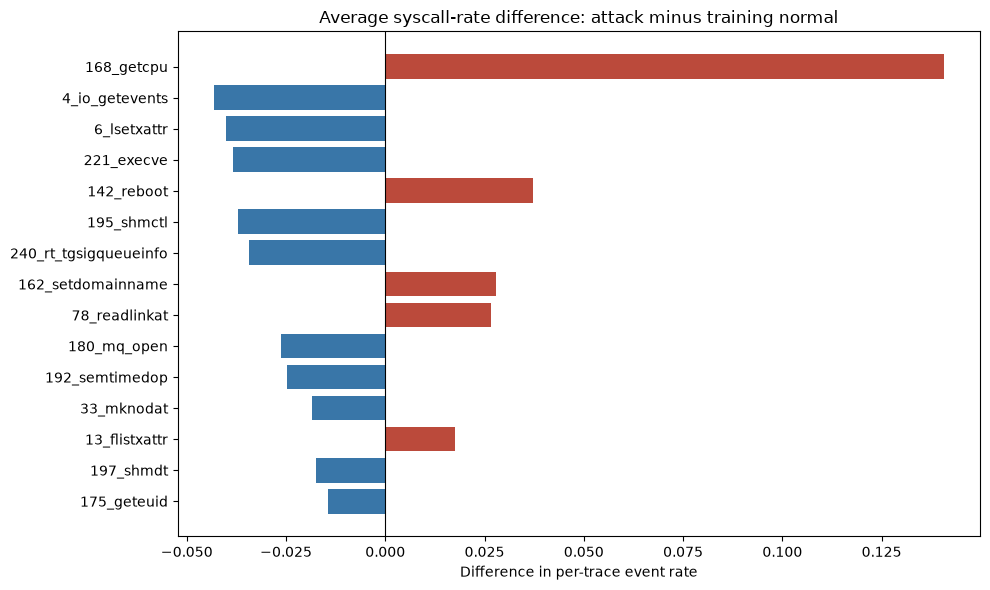

In [26]:
normal_rows = [row for row in exported_rows if row["partition"] == "training_normal"]
attack_rows = [row for row in exported_rows if row["partition"] == "attack"]
syscall_columns = [
    column for column in fieldnames
    if column.startswith("syscall_rate_")
]
profile_differences = []
for column in syscall_columns:
    normal_mean = np.mean([float(row[column]) for row in normal_rows]) if normal_rows else 0.0
    attack_mean = np.mean([float(row[column]) for row in attack_rows]) if attack_rows else 0.0
    profile_differences.append((abs(attack_mean - normal_mean), column, normal_mean, attack_mean))
profile_differences.sort(reverse=True)

print("Largest average syscall-rate differences (attack minus training normal):")
for difference, column, normal_mean, attack_mean in profile_differences[:15]:
    syscall_name = column.removeprefix("syscall_rate_")
    print(f"{syscall_name}: normal={normal_mean:.5f}, attack={attack_mean:.5f}, difference={attack_mean - normal_mean:+.5f}")

top_differences = profile_differences[:15]
plot_labels = [item[1].removeprefix("syscall_rate_") for item in top_differences][::-1]
plot_values = [item[3] - item[2] for item in top_differences][::-1]
plot_colors = ["#bb4a3b" if value > 0 else "#3976a8" for value in plot_values]
fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(plot_labels, plot_values, color=plot_colors)
ax.axvline(0, color="black", linewidth=0.8)
ax.set(title="Average syscall-rate difference: attack minus training normal", xlabel="Difference in per-trace event rate")
fig.tight_layout()
plt.show()

## Interpretation and submission notes

`submission/ADFA-LD_host_preprocessed.csv` is generated by calling the existing `HostLogPreprocessor` and summarizing its `PreprocessedData.x` windows. It is the compact file for this analysis and a candidate feature table for DBSCAN. The original ordered window tensor is produced per trace by the same class; rerun the preprocessor when the CNN needs that full sequence input. `partition`, `family`, `label`, and `source_file` are metadata, not DBSCAN features.

For CNN classification, preserve the current preprocessor's ordered windows and keep all windows from a source trace in one data split. For DBSCAN, choose one class, remove metadata/labels from the feature matrix, scale features, cluster, then compare cluster composition and cluster feature means against the selected class. These steps require no changes to CNN or DBSCAN source code.

The current preprocessor uses random embeddings; the notebook seeds its existing random-number generator consistently per trace for reproducible summaries. Its output remains subject to the current preprocessor's behavior and limitations; this analysis does not claim model accuracy.